# Behavioral-State HMM — graph-location-level state inference

Infer a latent behavioral state (e.g. **explore**, **exploit / goal-directed**,
**change-of-mind**) for the mouse at **each node-visit** (graph location), using
unsupervised HMMs on behavioral features derived from the traversal tables.

**Pipeline:** features (`navigraph.analysis.state_features`) → fit two model
families across K=2..5 → model selection (held-out LL / AIC / BIC) → **anchor-based
validation** (no ground truth) → plots → optional neural check.

**Model families**
1. **IO-HMM** (input-driven): behavioral covariates → state → `turn_type` emission
   (this is the GLM-HMM-equivalent; a native `ssm` GLM-HMM would need a C++ compiler,
   absent here, so IO-HMM represents the input-driven family).
2. **Gaussian-HMM** baseline: multivariate-Gaussian emissions on the continuous
   feature vector (no input/output).

**Anchors (weak labels):** `exploit` = direct alternation within a reward patch;
`change_of_mind` = path-commitment apex (`change_of_mind.ipynb`); `explore` = node on
a long indirect (detour) path.

In [1]:
import sys, os, warnings, json
from pathlib import Path
warnings.simplefilter("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# --- make the navigraph package importable (repo root = two levels up) ---
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "navigraph").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from navigraph.analysis.state_features import (
    build_graph_from_full_maze, build_state_feature_frame, add_weak_labels,
    build_design_matrix, validate_states,
    CONTINUOUS_FEATURES, BINARY_FEATURES, TURN_CATEGORIES,
)

# --- config ---
SESSION   = "10_09_2025"            # richest session (node_df + neural); turn_type
                                     # is computed from the graph, so node_df is all
                                     # that's required (works for any session)
FPS       = 40
K_RANGE   = [2, 3, 4, 5]
N_SEEDS   = 5                        # per-config restarts (best log-lik kept); the
                                     # unsupervised IO-HMM occasionally hits a
                                     # near-separable class split and a seed fails
                                     # to converge -- more restarts lowers the odds
                                     # every seed fails for a given (family, K)
FIT_TIMEOUT_S = 90                   # hard wall-clock cap per model fit (see cell below)
BASE      = REPO_ROOT / "examples" / "dual_root_tree" / "resources" / "outputs" / SESSION
FULL_MAZE = REPO_ROOT / "FullMazeGrid.pkl"
OUT_DIR   = BASE / "state_hmm"
OUT_DIR.mkdir(exist_ok=True)
print("repo:", REPO_ROOT, "\nsession dir exists:", BASE.exists())

repo: /var/home/almogmeir/Documents/GitHub/NaviGraph 
session dir exists: True


## 1. Load data, build features + weak-label anchors

In [2]:
node_df = pd.read_csv(BASE / "node_df.csv")
summary_df = pd.read_csv(BASE / "summary_df.csv", header=[0, 1])   # frame-level pose (MultiIndex cols)
try:
    dopp = pd.read_csv(BASE / "direct_opportunities_unique_paths.csv")   # commitment apexes
except FileNotFoundError:
    dopp = None
    print("No direct_opportunities file -> change_of_mind anchor disabled")

G = build_graph_from_full_maze(FULL_MAZE)

# turn_type is computed directly from G (see state_features.turns_from_graph), not
# joined from a precomputed turn_df.csv -- this avoids the spurious NONEs a per-trial
# turn_df walk produces at every trial/reward boundary, and works for any session.
feat = build_state_feature_frame(node_df, summary_df, G, fps=FPS)
feat = add_weak_labels(feat, dopp)
print("feature rows:", len(feat), "| node_df rows:", len(node_df))
print("anchors:",
      "exploit =", int(feat.anchor_exploit.sum()),
      "| explore =", int(feat.anchor_explore.sum()),
      "| change_of_mind =", int(feat.anchor_change_of_mind.sum()))
feat.head()

feature rows: 5858 | node_df rows: 5858
anchors: exploit = 3057 | explore = 321 | change_of_mind = 17


,node_visit_idx,node_name,trial_idx,start_frame,end_frame,port_to_port_path_type,path_pair_label,_seg,speed_mean,log_dwell,...,is_port_node,reward_during_node,is_indirect,is_alternation,turn_type,prev_turn_type,graph_angle_deg,anchor_exploit,anchor_explore,anchor_change_of_mind
0,0,L31,0,12,12,NaN,NaN,-1,NaN,0.693147,...,0,0,0,0,NONE,NONE,NaN,False,False,False
1,1,L20,0,14,14,NaN,NaN,-1,459.511858,0.693147,...,0,0,0,0,STRAIGHT,NONE,0.0,False,False,False
2,2,L30,0,16,16,NaN,NaN,-1,429.244683,0.693147,...,0,0,0,0,RIGHT,STRAIGHT,90.0,False,False,False
3,3,L40,0,18,18,NaN,NaN,-1,388.622791,0.693147,...,0,0,0,0,RIGHT,RIGHT,90.0,False,False,False
4,4,L50,0,19,20,NaN,NaN,-1,455.459771,1.098612,...,0,0,0,0,UTURN,RIGHT,180.0,False,False,False


In [3]:
# numeric covariate matrix (z-scored continuous + 0/1 binary; winsorized, NaN-imputed)
X, COVS = build_design_matrix(feat)
turn_out = feat["turn_type"].astype(str).values
print("design matrix:", X.shape, "| covariates:", COVS)
print("turn distribution:", feat["turn_type"].value_counts().to_dict())

design matrix: (5858, 12) | covariates: ['speed_mean', 'log_dwell', 'node_depth', 'dist_to_goal', 'path_excess', 'log_frames_since_reward', 'local_reward_rate', 'abs_graph_angle', 'is_port_node', 'reward_during_node', 'is_indirect', 'is_alternation']
turn distribution: {'LEFT': 1831, 'RIGHT': 1741, 'UTURN': 1383, 'STRAIGHT': 625, 'NONE': 278}


## 2. Fit the two model families across K = 2..5

For each family and K we fit `N_SEEDS` restarts and keep the best training
log-likelihood. We record LL, AIC, BIC, and a held-out log-likelihood from a
trial-blocked split (hold out every 5th trial).

In [4]:
# ---------- sklearn compat shim: IOHMM 0.0.7 calls label_binarize positionally ----------
import sklearn.preprocessing as _skp
import IOHMM.linear_models as _iolm
_orig_lb = _skp.label_binarize
_iolm.label_binarize = lambda Y, classes, **k: _orig_lb(Y, classes=classes, **k)

from IOHMM import UnSupervisedIOHMM, DiscreteMNL, CrossEntropyMNL
from hmmlearn.hmm import GaussianHMM

import signal
from contextlib import contextmanager

@contextmanager
def time_limit(seconds):
    """Hard wall-clock cap for a single model fit (Unix only).

    A handful of (K, seed) combinations can pathologically slow down the inner
    LBFGS solver; this guarantees the K-sweep below finishes in bounded time
    regardless of cause, by raising TimeoutError past FIT_TIMEOUT_S.
    """
    def _handler(signum, frame):
        raise TimeoutError(f"fit exceeded {seconds}s")
    old = signal.signal(signal.SIGALRM, _handler)
    signal.alarm(seconds)
    try:
        yield
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old)


def _trial_blocked_mask(trial_idx, every=5):
    """Boolean test mask: every `every`-th trial id is held out."""
    uniq = np.sort(pd.unique(trial_idx))
    test_trials = set(uniq[::every])
    return np.isin(trial_idx, list(test_trials))


TEST = _trial_blocked_mask(feat["trial_idx"].values, every=5)
TRAIN = ~TEST
print(f"held-out node-visits: {TEST.sum()} / {len(TEST)}  ({TEST.mean():.0%})")

held-out node-visits: 1229 / 5858  (21%)


In [5]:
# ---------- Gaussian-HMM baseline ----------
def fit_gaussian(K, Xmat, seed=0, n_iter=150):
    m = GaussianHMM(n_components=K, covariance_type="diag", n_iter=n_iter,
                    random_state=seed)
    with time_limit(FIT_TIMEOUT_S):
        m.fit(Xmat)
    return m

def gaussian_scores(K, seeds=range(N_SEEDS)):
    best = None
    for s in seeds:
        try:
            m = fit_gaussian(K, X, seed=s)
            ll = m.score(X)
        except Exception:
            continue
        if best is None or ll > best[0]:
            best = (ll, m, s)
    if best is None:
        raise RuntimeError(f"Gaussian-HMM: all {len(list(seeds))} seeds failed/timed out at K={K}")
    ll, m, s = best
    states = m.predict(X)
    n_params = K * X.shape[1] * 2 + K * (K - 1) + (K - 1)   # means+vars + trans + init
    aic = -2 * ll + 2 * n_params
    bic = -2 * ll + n_params * np.log(len(X))
    # held-out LL: refit on train, score test
    try:
        m_tr = fit_gaussian(K, X[TRAIN], seed=s)
        ll_test = m_tr.score(X[TEST])
    except Exception:
        ll_test = np.nan
    return dict(family="Gaussian", K=K, ll=ll, aic=aic, bic=bic,
                ll_test=ll_test, seed=s, model=m, states=states)

In [6]:
# ---------- IO-HMM / GLM-HMM (input-driven; turn_type emission) ----------
def _io_frame(Xmat, turn):
    d = pd.DataFrame(Xmat, columns=COVS)
    d["turn"] = turn
    return d

def fit_iohmm(K, Xmat, turn, seed=0, max_em_iter=25, em_tol=1e-3, inner_max_iter=50, alpha=1.0):
    # alpha is the L2 regularization strength for DiscreteMNL/CrossEntropyMNL. IOHMM
    # defaults alpha=0, which the library treats as "no regularization at all"
    # (internally C = 1/alpha -> inf). Unregularized MNL blows up toward perfect
    # separation once K>=4 gives the emission/transition models enough freedom to
    # carve out near-empty turn-class slices, producing NaN sample weights and
    # crashing every seed. alpha=1.0 (~ sklearn LogisticRegression's default C=1)
    # keeps coefficients bounded and made K=3/4/5 converge cleanly (5/5 seeds each,
    # verified standalone) where they previously all failed.
    #
    # inner_max_iter caps the per-M-step LBFGS solver iterations; with real
    # regularization this is now just a speed cap, not a stability workaround.
    np.random.seed(seed)
    mod = UnSupervisedIOHMM(num_states=K, max_EM_iter=max_em_iter, EM_tol=em_tol)
    mod.set_models(model_emissions=[DiscreteMNL(reg_method="l2", alpha=alpha, max_iter=inner_max_iter)],
                   model_transition=CrossEntropyMNL(solver="lbfgs", reg_method="l2", alpha=alpha,
                                                     max_iter=inner_max_iter),
                   model_initial=CrossEntropyMNL(solver="lbfgs", reg_method="l2", alpha=alpha,
                                                  max_iter=inner_max_iter))
    mod.set_inputs(covariates_initial=[], covariates_transition=COVS,
                   covariates_emissions=[COVS])
    mod.set_outputs([["turn"]])
    mod.set_data([_io_frame(Xmat, turn)])
    with time_limit(FIT_TIMEOUT_S):
        mod.train()
    return mod

def io_states(mod):
    return np.array(mod.log_gammas[0]).argmax(1)

def iohmm_scores(K, seeds=range(N_SEEDS)):
    best = None
    for s in seeds:
        try:
            mod = fit_iohmm(K, X, turn_out, seed=s)
            ll = float(np.array(mod.log_likelihoods)[-1])
        except Exception:
            continue
        if best is None or ll > best[0]:
            best = (ll, mod, s)
    if best is None:
        raise RuntimeError(f"IO-HMM: all {len(list(seeds))} seeds failed/timed out at K={K}")
    ll, mod, s = best
    states = io_states(mod)
    # param count ~ emissions (K * n_turn_classes * (p+1)) + transitions (K*K*(p+1)) + init
    p = X.shape[1]; C = len(set(turn_out))
    n_params = K * C * (p + 1) + K * K * (p + 1) + (K - 1)
    aic = -2 * ll + 2 * n_params
    bic = -2 * ll + n_params * np.log(len(X))
    return dict(family="IO-HMM", K=K, ll=ll, aic=aic, bic=bic,
                ll_test=np.nan, seed=s, model=mod, states=states)

In [7]:
results = {}
for K in K_RANGE:
    for fam, fn in [("Gaussian", gaussian_scores), ("IO-HMM", iohmm_scores)]:
        try:
            results[(fam, K)] = fn(K)
        except RuntimeError as e:
            # all seeds failed/timed out for this (family, K) -- skip it rather than
            # aborting the whole sweep; occasional numerical instability (near-separable
            # turn classes) at higher K is expected for the unsupervised IO-HMM.
            print(f"SKIPPED {fam} K={K}: {e}")
    row = []
    for fam in ("Gaussian", "IO-HMM"):
        r = results.get((fam, K))
        row.append(f"{fam} LL={r['ll']:.0f} BIC={r['bic']:.0f}" if r else f"{fam}=SKIPPED")
    print(f"K={K}: " + " | ".join(row))

K=2: Gaussian LL=-14653 BIC=29748 | IO-HMM LL=-2530 BIC=6648


K=3: Gaussian LL=36527 BIC=-72359 | IO-HMM LL=-2550 BIC=7823


K=4: Gaussian LL=41635 BIC=-82307 | IO-HMM LL=-2567 BIC=9220


K=5: Gaussian LL=58664 BIC=-116079 | IO-HMM LL=-2583 BIC=10841


## 3. Model selection — LL / AIC / BIC / held-out

,family,K,logLik,AIC,BIC,heldout_LL
0,Gaussian,2,-14652.755204,29407.510407,29747.964147,-3680.170358
1,Gaussian,3,36526.593059,-72893.186118,-72359.141036,-2763.061279
2,Gaussian,4,41634.985439,-83047.970878,-82306.983326,-99649.796386
3,Gaussian,5,58663.969330,-117039.938659,-116078.657511,-99085.852594
4,IO-HMM,2,-2530.169595,5426.339189,6647.967315,NaN
5,IO-HMM,3,-2549.643996,5727.287992,7823.414939,NaN
6,IO-HMM,4,-2567.148786,6076.297572,9220.487993,NaN
7,IO-HMM,5,-2583.434877,6474.869755,10840.688302,NaN


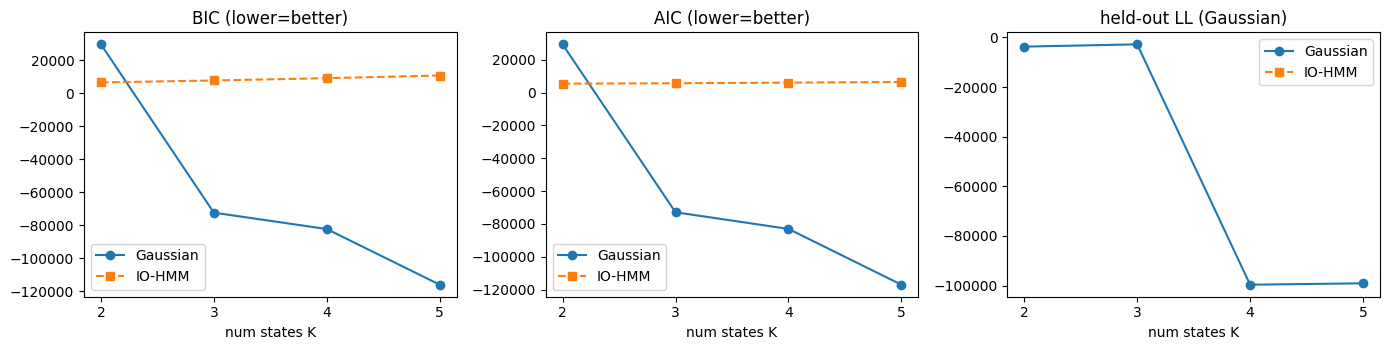

In [8]:
sel = pd.DataFrame([
    {"family": r["family"], "K": r["K"], "logLik": r["ll"],
     "AIC": r["aic"], "BIC": r["bic"], "heldout_LL": r["ll_test"]}
    for r in results.values()
]).sort_values(["family", "K"]).reset_index(drop=True)
display(sel)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for fam, mk in [("Gaussian", "o-"), ("IO-HMM", "s--")]:
    sub = sel[sel.family == fam]
    axes[0].plot(sub.K, sub.BIC, mk, label=fam)
    axes[1].plot(sub.K, sub.AIC, mk, label=fam)
    axes[2].plot(sub.K, sub.heldout_LL, mk, label=fam)
for ax, t in zip(axes, ["BIC (lower=better)", "AIC (lower=better)", "held-out LL (Gaussian)"]):
    ax.set_xlabel("num states K"); ax.set_title(t); ax.legend(); ax.set_xticks(K_RANGE)
fig.tight_layout(); fig.savefig(OUT_DIR / "model_selection.png", dpi=130); plt.show()

## 4. Anchor-based validation (no ground truth)

For a chosen model we score every state's enrichment at each anchor
(Fisher odds-ratio, one-sided). A good model has a **distinct** state enriched
for each anchor: one for `exploit` (alternation), one for `change_of_mind`
(commitment apex), one for `explore` (long detour).

In [9]:
# choose the model to inspect — default IO-HMM at the BIC-best K
CHOSEN_FAMILY = "IO-HMM"
_bic_best_K = int(sel[sel.family == CHOSEN_FAMILY].sort_values("BIC").iloc[0].K)
CHOSEN_K = _bic_best_K
print(f"Inspecting {CHOSEN_FAMILY} K={CHOSEN_K} (BIC-best for this family)")

chosen = results[(CHOSEN_FAMILY, CHOSEN_K)]
feat["state"] = chosen["states"]
report = validate_states(chosen["states"], feat)

print("\n=== anchor enrichment ===")
for anc, d in report["enrichment"].items():
    print(f"{anc:22} best_state={d['best_state']}  OR={d['best_odds_ratio']:.2f}  "
          f"p={d['best_p']:.1e}  (n_anchor={d['n_anchor']})")
print("\noccupancy:", {k: round(v, 3) for k, v in report["occupancy"].items()})
print("stickiness (self-transition):",
      {k: round(v['p_self'], 2) for k, v in report["stickiness"].items()})
print("mean dwell:", {k: round(v['mean_dwell'], 1) for k, v in report["stickiness"].items()})

Inspecting IO-HMM K=2 (BIC-best for this family)

=== anchor enrichment ===
anchor_exploit         best_state=1  OR=5.13  p=8.1e-186  (n_anchor=3057)
anchor_change_of_mind  best_state=1  OR=1.69  p=2.0e-01  (n_anchor=17)
anchor_explore         best_state=0  OR=1.82  p=8.9e-07  (n_anchor=321)

occupancy: {0: 0.6, 1: 0.4}
stickiness (self-transition): {0: 0.66, 1: 0.49}
mean dwell: {0: 2.9, 1: 2.0}


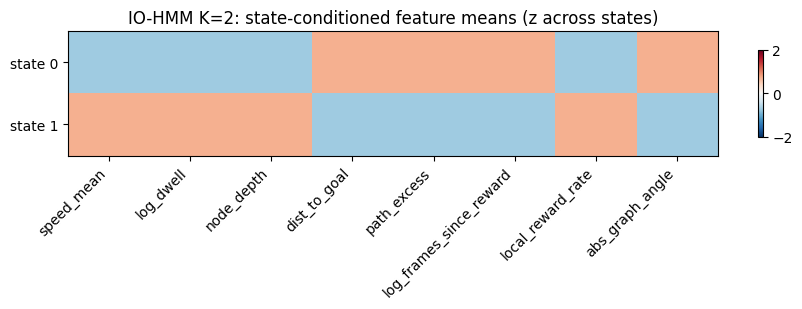

In [10]:
# state-conditioned feature means (face validity)
sfm = report["state_feature_means"]
fig, ax = plt.subplots(figsize=(9, 0.6 * len(sfm) + 2))
z = (sfm - sfm.mean()) / sfm.std()
im = ax.imshow(z.values, cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2)
ax.set_xticks(range(len(sfm.columns))); ax.set_xticklabels(sfm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(sfm.index))); ax.set_yticklabels([f"state {i}" for i in sfm.index])
ax.set_title(f"{CHOSEN_FAMILY} K={CHOSEN_K}: state-conditioned feature means (z across states)")
fig.colorbar(im, ax=ax, shrink=0.7); fig.tight_layout()
fig.savefig(OUT_DIR / "state_feature_means.png", dpi=130); plt.show()

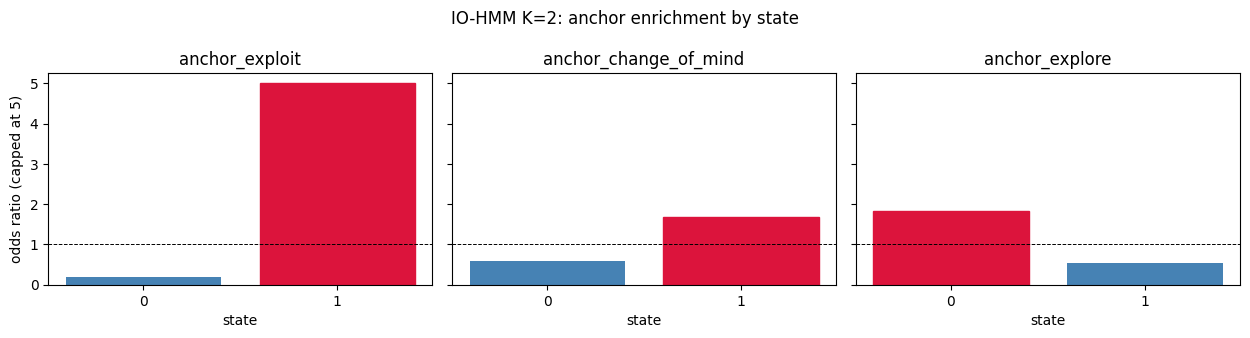

In [11]:
# anchor enrichment bars: odds-ratio per state per anchor
ancs = list(report["enrichment"].keys())
states = sorted(feat["state"].unique())
fig, axes = plt.subplots(1, len(ancs), figsize=(4.2 * len(ancs), 3.4), sharey=True)
for ax, anc in zip(np.atleast_1d(axes), ancs):
    ors = [report["enrichment"][anc]["per_state"][s]["odds_ratio"] for s in states]
    ors = [min(o, 5) if np.isfinite(o) else 0 for o in ors]
    bars = ax.bar([str(s) for s in states], ors, color="steelblue")
    best = report["enrichment"][anc]["best_state"]
    bars[states.index(best)].set_color("crimson")
    ax.axhline(1, color="k", lw=0.7, ls="--"); ax.set_title(anc); ax.set_xlabel("state")
axes[0].set_ylabel("odds ratio (capped at 5)")
fig.suptitle(f"{CHOSEN_FAMILY} K={CHOSEN_K}: anchor enrichment by state"); fig.tight_layout()
fig.savefig(OUT_DIR / "anchor_enrichment.png", dpi=130); plt.show()

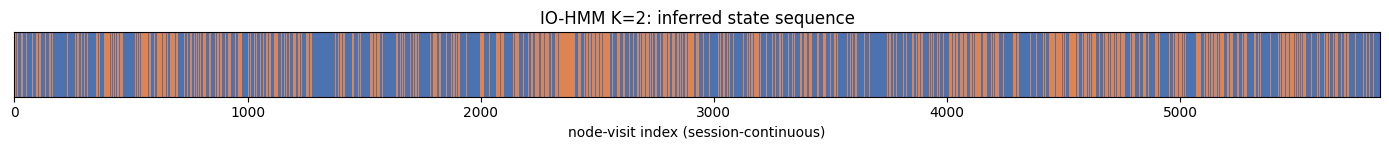

In [12]:
# state raster over node-visit index (colored strip) + occupancy
from matplotlib.colors import ListedColormap
palette = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3"]
cmap = ListedColormap(palette[:len(states)])
fig, ax = plt.subplots(figsize=(14, 1.6))
ax.imshow(feat["state"].values[None, :], aspect="auto", cmap=cmap,
          interpolation="nearest")
ax.set_yticks([]); ax.set_xlabel("node-visit index (session-continuous)")
ax.set_title(f"{CHOSEN_FAMILY} K={CHOSEN_K}: inferred state sequence")
fig.tight_layout(); fig.savefig(OUT_DIR / "state_raster.png", dpi=130); plt.show()

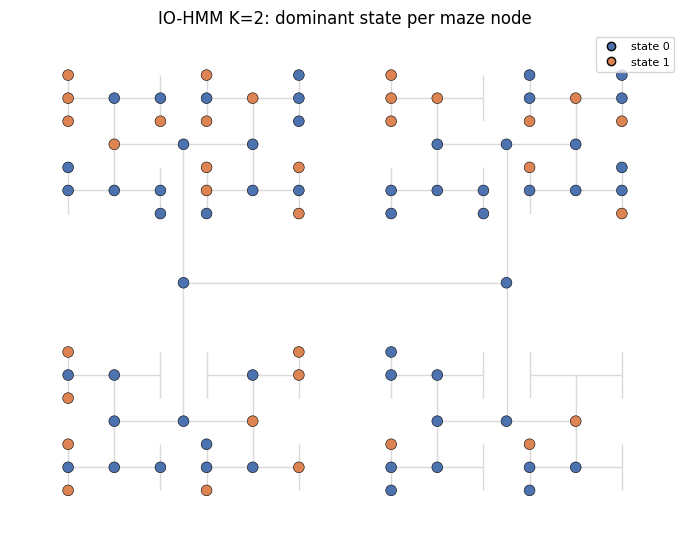

In [13]:
# states on the maze: per node, the most frequent state across its visits
pos = nx.get_node_attributes(G, "pos")
node_state = feat.groupby("node_name")["state"].agg(lambda s: s.value_counts().idxmax())
fig, ax = plt.subplots(figsize=(7, 7))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="0.85")
xs = [pos[n][0] for n in node_state.index]; ys = [pos[n][1] for n in node_state.index]
cols = [palette[int(s)] for s in node_state.values]
ax.scatter(xs, ys, c=cols, s=60, edgecolors="k", linewidths=0.4, zorder=3)
ax.invert_yaxis(); ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"{CHOSEN_FAMILY} K={CHOSEN_K}: dominant state per maze node")
handles = [plt.Line2D([0],[0], marker='o', ls='', mfc=palette[i], mec='k',
           label=f"state {i}") for i in states]
ax.legend(handles=handles, loc="upper right", fontsize=8)
fig.tight_layout(); fig.savefig(OUT_DIR / "state_on_maze.png", dpi=130); plt.show()

## 4B. GLM-HMM (IO-HMM) deep dive: K = 3, 4, 5

Focused comparison of the input-driven GLM-HMM across three state counts (the
Gaussian-HMM baseline is left aside here — see Section 3 for that comparison).
For each K we look at:

1. **Where transitions occur** — the inferred state sequence plotted against the
   three behavioral anchors (exploit/alternation, change-of-mind, explore), so
   state switches can be read directly against what the mouse was doing.
2. **Does alternation stay in one state?** — for every direct within-patch
   alternation path (`anchor_exploit`), the fraction of its node-visits sharing
   the single most common state ("purity"). Near-1.0 across paths means exploit
   behavior is captured by one sticky state.
3. **Is change-of-mind a rare, distinct state?** — for each of the path-commitment
   apex events, the state trace in a window around the apex, plus whether the
   apex lands disproportionately often in one state relative to that state's
   overall (baseline) occupancy.
4. **Empirical transition matrix** and **maze overlay** for spatial/temporal context.

In [14]:
DEEPDIVE_K = [3, 4, 5]

# refit (or reuse from the Section 2 sweep) IO-HMM states for each K, and rebuild
# validate_states() reports so this section is self-contained even if Section 2
# skipped a K for some reason.
states_by_K = {}
report_by_K = {}
for K in DEEPDIVE_K:
    r = results.get(("IO-HMM", K))
    if r is None:
        print(f"K={K} missing from Section 2 results -- refitting now")
        r = iohmm_scores(K)
        results[("IO-HMM", K)] = r
    states_by_K[K] = r["states"]
    feat[f"state_K{K}"] = r["states"]
    report_by_K[K] = validate_states(r["states"], feat)
print("states available for K =", list(states_by_K.keys()))


def empirical_transition_matrix(states, K):
    """Row-normalized count of observed state[t] -> state[t+1] transitions."""
    states = np.asarray(states)
    mat = np.zeros((K, K))
    for a, b in zip(states[:-1], states[1:]):
        mat[a, b] += 1
    row_sums = mat.sum(axis=1, keepdims=True)
    return np.divide(mat, row_sums, out=np.zeros_like(mat), where=row_sums > 0)


def alternation_purity(feat, state_col):
    """Per-alternation-segment fraction of node-visits in that segment's single
    most common state. One value per direct within-patch alternation path."""
    seg_ids = feat.loc[feat["anchor_exploit"], "_seg"].unique()
    purities, dominant_states = [], []
    for s in seg_ids:
        vals = feat.loc[feat["_seg"] == s, state_col]
        vc = vals.value_counts(normalize=True)
        purities.append(vc.iloc[0])
        dominant_states.append(vc.index[0])
    return np.array(purities), np.array(dominant_states), seg_ids


def change_of_mind_window(feat, state_col, window=6):
    """State trace around each change-of-mind apex, relative node-visit index
    offset -window..+window (0 = the apex itself)."""
    apex_idx = feat.loc[feat["anchor_change_of_mind"], "node_visit_idx"].values
    state_arr = feat.set_index("node_visit_idx")[state_col]
    mat = np.full((len(apex_idx), 2 * window + 1), np.nan)
    for i, a in enumerate(apex_idx):
        for j, off in enumerate(range(-window, window + 1)):
            mat[i, j] = state_arr.get(a + off, np.nan)
    return mat, apex_idx

states available for K = [3, 4, 5]


### 4B.1 Where do transitions occur? State raster vs. behavioral anchors

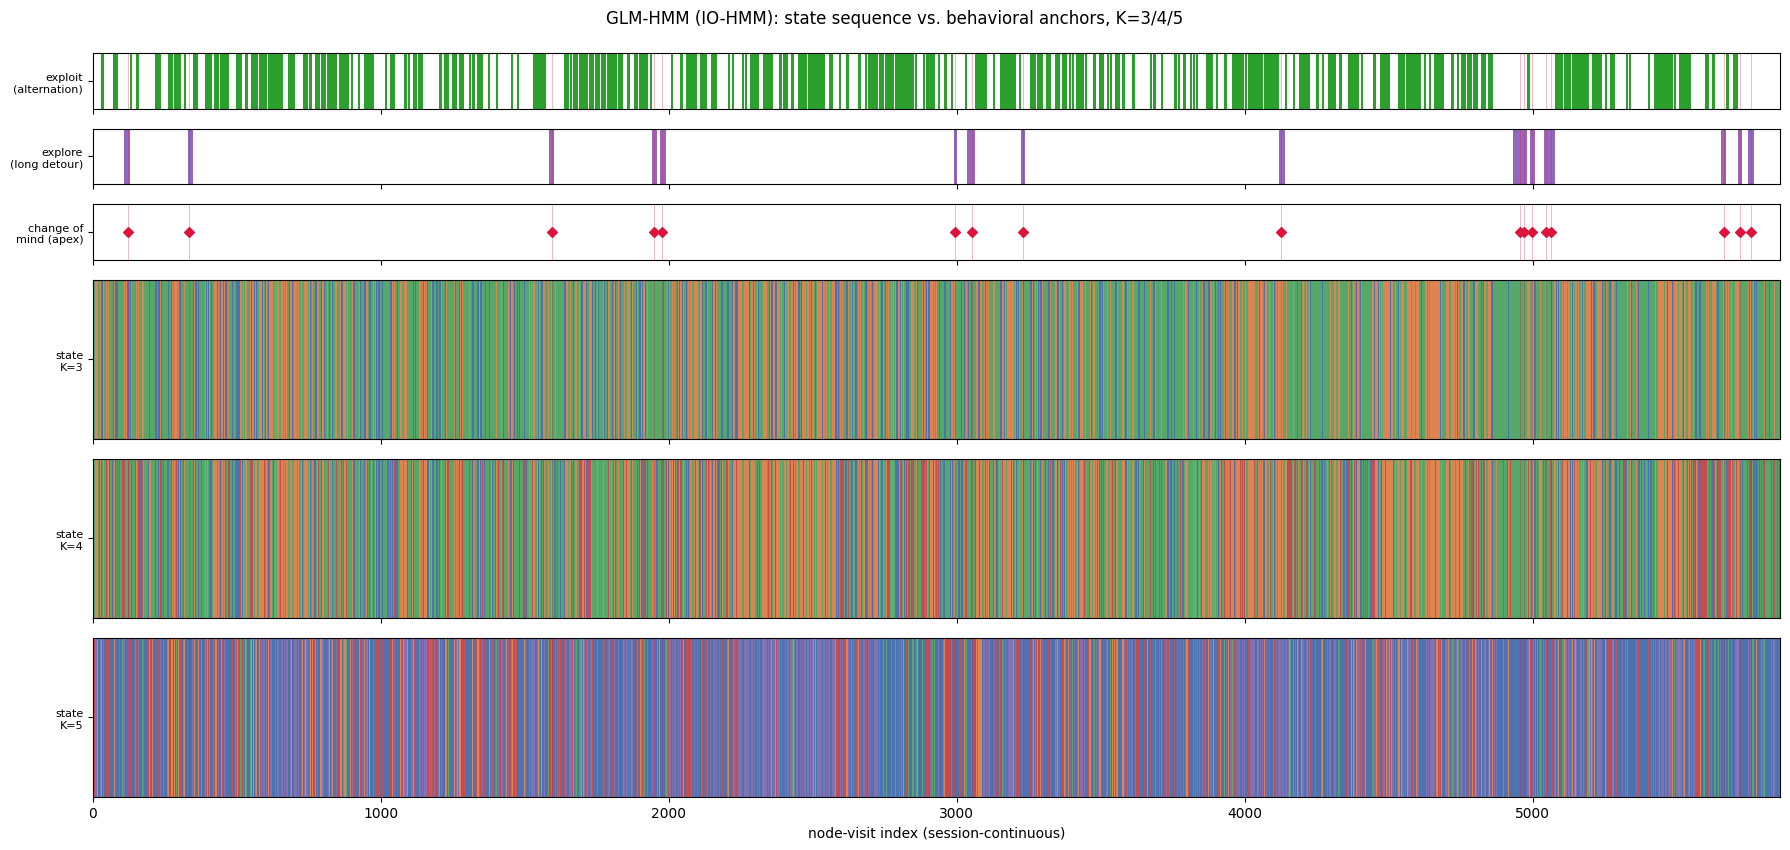

In [15]:
# Full-session overview: anchor strips (top) vs. inferred state strips (bottom, K=3/4/5),
# all sharing the same x-axis (node-visit index). Change-of-mind apex events are marked
# with a red diamond and a vertical guide line spanning every row, so it's immediate to
# see whether a state switch coincides with a commitment event.
from matplotlib.colors import ListedColormap, BoundaryNorm

palette = ["#4c72b0", "#dd8452", "#55a868", "#c44e52", "#8172b3"]
n_visits = len(feat)
apex_x = feat.loc[feat["anchor_change_of_mind"], "node_visit_idx"].values

fig, axes = plt.subplots(
    6, 1, figsize=(18, 8.5), sharex=True,
    gridspec_kw={"height_ratios": [0.35, 0.35, 0.35, 1, 1, 1]},
)

for ax, col, label, color in zip(
    axes[:2], ["anchor_exploit", "anchor_explore"], ["exploit\n(alternation)", "explore\n(long detour)"],
    ["#2ca02c", "#9467bd"],
):
    v = feat[col].values.astype(float)[None, :]
    ax.imshow(v, aspect="auto", cmap=ListedColormap(["white", color]), vmin=0, vmax=1,
              interpolation="nearest", extent=[0, n_visits, 0, 1])
    ax.set_yticks([0.5]); ax.set_yticklabels([label], fontsize=8)
    ax.set_ylim(0, 1)

ax = axes[2]
ax.scatter(apex_x, np.zeros_like(apex_x), marker="D", color="crimson", s=25, zorder=3)
ax.set_yticks([0]); ax.set_yticklabels(["change of\nmind (apex)"], fontsize=8)
ax.set_ylim(-0.5, 0.5)

for ax, K in zip(axes[3:], DEEPDIVE_K):
    st = states_by_K[K]
    cmap = ListedColormap(palette[:K])
    ax.imshow(st[None, :], aspect="auto", cmap=cmap, vmin=-0.5, vmax=K - 0.5,
              interpolation="nearest", extent=[0, n_visits, 0, 1])
    ax.set_yticks([0.5]); ax.set_yticklabels([f"state\nK={K}"], fontsize=8)
    ax.set_ylim(0, 1)

for ax in axes:
    for x in apex_x:
        ax.axvline(x, color="crimson", linewidth=0.6, alpha=0.35, zorder=1)

axes[-1].set_xlabel("node-visit index (session-continuous)")
fig.suptitle("GLM-HMM (IO-HMM): state sequence vs. behavioral anchors, K=3/4/5", y=0.995)
fig.tight_layout()
fig.savefig(OUT_DIR / "deepdive_raster_overview.png", dpi=140)
plt.show()

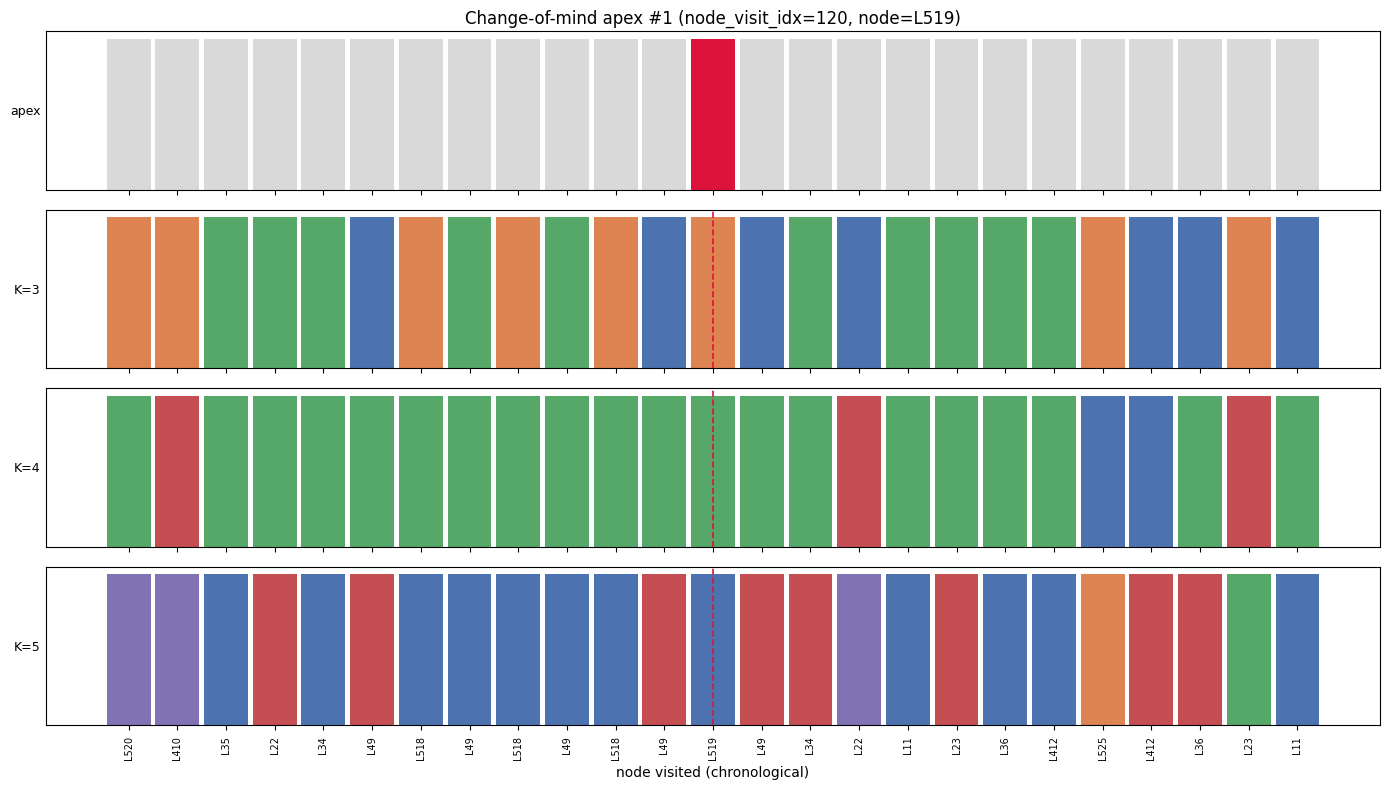

In [16]:
# Zoom-in on one change-of-mind apex (the session-overview raster is too dense at this
# scale to see individual node-visits). Shows node names, turn_type, and state K=3/4/5
# in a window around the commitment moment.
ZOOM_HALF_WINDOW = 12
zoom_apex = int(apex_x[0])
lo, hi = max(0, zoom_apex - ZOOM_HALF_WINDOW), min(n_visits - 1, zoom_apex + ZOOM_HALF_WINDOW)
sub = feat[(feat["node_visit_idx"] >= lo) & (feat["node_visit_idx"] <= hi)].sort_values("node_visit_idx")

fig, axes = plt.subplots(len(DEEPDIVE_K) + 1, 1, figsize=(14, 2.0 * (len(DEEPDIVE_K) + 1)),
                          sharex=True)
x = sub["node_visit_idx"].values

ax = axes[0]
colors = ["crimson" if v else "0.85" for v in sub["anchor_change_of_mind"]]
ax.bar(x, np.ones(len(x)), color=colors, width=0.9)
ax.set_yticks([]); ax.set_ylabel("apex", fontsize=9, rotation=0, ha="right", va="center")
ax.set_title(f"Change-of-mind apex #{1} (node_visit_idx={zoom_apex}, node={feat.loc[feat.node_visit_idx==zoom_apex,'node_name'].iloc[0]})")

for ax, K in zip(axes[1:], DEEPDIVE_K):
    st = sub[f"state_K{K}"].values
    cmap = ListedColormap(palette[:K])
    ax.bar(x, np.ones(len(x)), color=[palette[s] for s in st], width=0.9)
    ax.set_yticks([]); ax.set_ylabel(f"K={K}", fontsize=9, rotation=0, ha="right", va="center")
    ax.axvline(zoom_apex, color="crimson", linewidth=1.2, linestyle="--", zorder=3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(sub["node_name"].values, rotation=90, fontsize=7)
axes[-1].set_xlabel("node visited (chronological)")
fig.tight_layout()
fig.savefig(OUT_DIR / "deepdive_apex_zoom.png", dpi=140)
plt.show()

### 4B.2 Empirical transition matrices (state[t] → state[t+1])

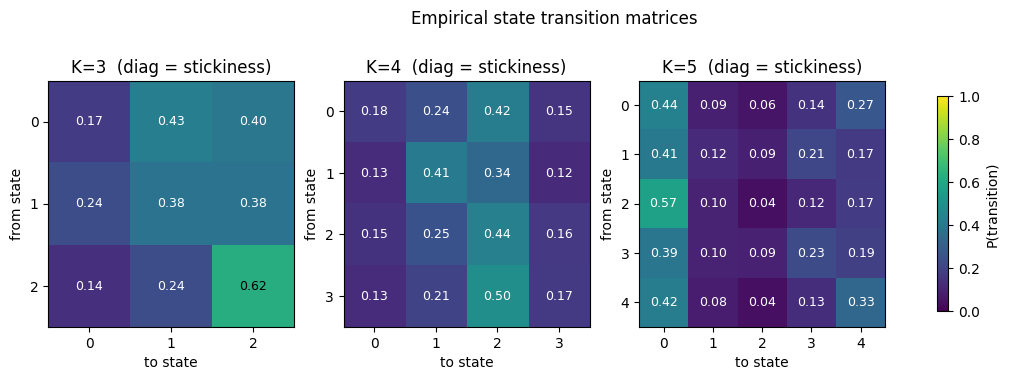

In [17]:
fig, axes = plt.subplots(1, len(DEEPDIVE_K), figsize=(4.5 * len(DEEPDIVE_K), 4))
for ax, K in zip(axes, DEEPDIVE_K):
    tm = empirical_transition_matrix(states_by_K[K], K)
    im = ax.imshow(tm, cmap="viridis", vmin=0, vmax=1)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f"{tm[i, j]:.2f}", ha="center", va="center",
                    color="white" if tm[i, j] < 0.6 else "black", fontsize=9)
    ax.set_xticks(range(K)); ax.set_yticks(range(K))
    ax.set_xlabel("to state"); ax.set_ylabel("from state")
    ax.set_title(f"K={K}  (diag = stickiness)")
fig.colorbar(im, ax=axes, shrink=0.7, label="P(transition)")
fig.suptitle("Empirical state transition matrices")
fig.savefig(OUT_DIR / "deepdive_transition_matrices.png", dpi=140, bbox_inches="tight")
plt.show()

### 4B.3 Does alternation (direct within-patch paths) stay in one state?

Each direct path between the two ports of the *same* reward patch (`anchor_exploit`)
is one contiguous run of node-visits. "Purity" = the fraction of that run's
node-visits sharing the single most common state. Purity = 1.0 means the whole
alternation trip was inferred as one state throughout.

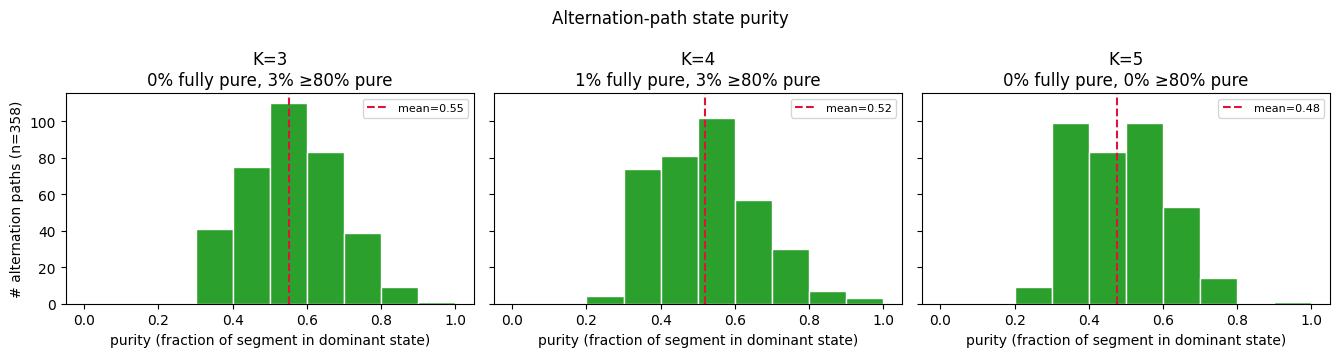

Alternation purity summary:
  K=3: n=358 paths | mean purity=0.553 | 0.3% fully single-state | 2.8% ≥80% single-state
  K=4: n=358 paths | mean purity=0.519 | 0.8% fully single-state | 2.8% ≥80% single-state
  K=5: n=358 paths | mean purity=0.477 | 0.3% fully single-state | 0.3% ≥80% single-state


In [18]:
fig, axes = plt.subplots(1, len(DEEPDIVE_K), figsize=(4.5 * len(DEEPDIVE_K), 3.6), sharey=True)
purity_stats = {}
for ax, K in zip(axes, DEEPDIVE_K):
    purities, dominant_states, seg_ids = alternation_purity(feat, f"state_K{K}")
    purity_stats[K] = dict(
        n_segments=len(purities),
        mean_purity=float(np.mean(purities)),
        pct_pure=float(np.mean(purities == 1.0)),
        pct_ge_80=float(np.mean(purities >= 0.8)),
    )
    ax.hist(purities, bins=np.linspace(0, 1, 11), color="#2ca02c", edgecolor="white")
    ax.axvline(np.mean(purities), color="crimson", linestyle="--",
               label=f"mean={np.mean(purities):.2f}")
    ax.set_title(f"K={K}\n{purity_stats[K]['pct_pure']:.0%} fully pure, "
                 f"{purity_stats[K]['pct_ge_80']:.0%} ≥80% pure")
    ax.set_xlabel("purity (fraction of segment in dominant state)")
    ax.legend(fontsize=8)
axes[0].set_ylabel(f"# alternation paths (n={purity_stats[DEEPDIVE_K[0]]['n_segments']})")
fig.suptitle("Alternation-path state purity")
fig.tight_layout()
fig.savefig(OUT_DIR / "deepdive_alternation_purity.png", dpi=140)
plt.show()

print("Alternation purity summary:")
for K in DEEPDIVE_K:
    s = purity_stats[K]
    print(f"  K={K}: n={s['n_segments']} paths | mean purity={s['mean_purity']:.3f} | "
          f"{s['pct_pure']:.1%} fully single-state | {s['pct_ge_80']:.1%} ≥80% single-state")

### 4B.4 Is change-of-mind captured by a rare, distinct state?

For each K: which state is most enriched at the 17 commitment-apex events
(from `validate_states`), how rare is that state overall (baseline occupancy),
and — visually — does a distinct state tend to appear right at offset 0 across
the apex events, or is it indistinguishable from the surrounding trace?

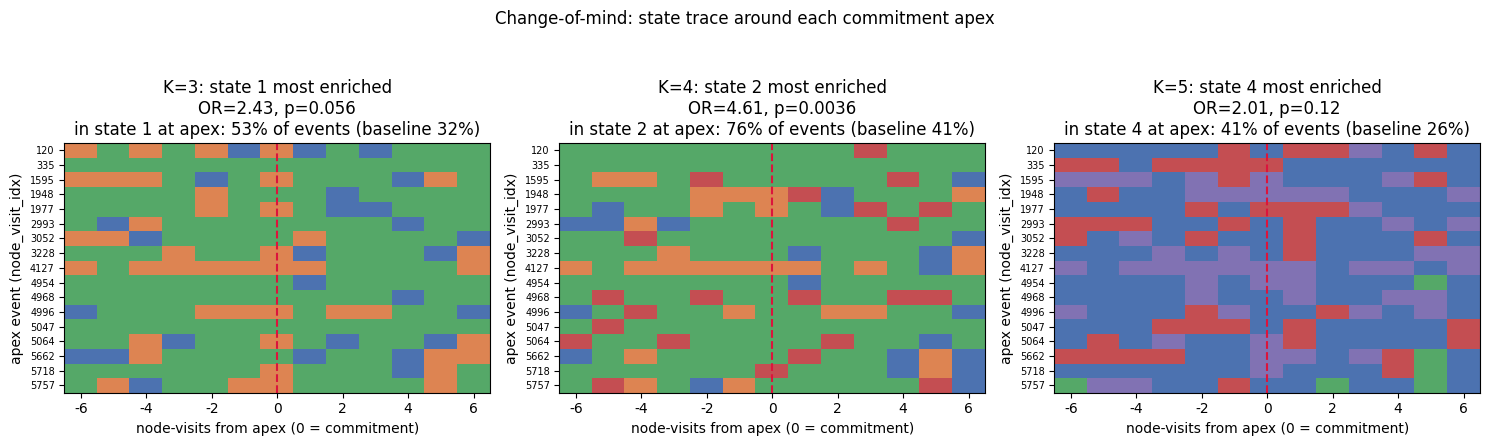

Change-of-mind capture summary:
  K=3: state 1 at apex in 52.9% of events vs 31.7% baseline occupancy (1.67x lift), OR=2.43, p=0.056
  K=4: state 2 at apex in 76.5% of events vs 41.4% baseline occupancy (1.84x lift), OR=4.61, p=0.00363
  K=5: state 4 at apex in 41.2% of events vs 25.9% baseline occupancy (1.59x lift), OR=2.01, p=0.124


In [19]:
COM_WINDOW = 6
fig, axes = plt.subplots(1, len(DEEPDIVE_K), figsize=(5 * len(DEEPDIVE_K), 4.2))
com_stats = {}
for ax, K in zip(axes, DEEPDIVE_K):
    mat, apex_idx = change_of_mind_window(feat, f"state_K{K}", window=COM_WINDOW)
    cmap = ListedColormap(palette[:K])
    masked = np.ma.masked_invalid(mat)
    ax.imshow(masked, aspect="auto", cmap=cmap, vmin=-0.5, vmax=K - 0.5,
              interpolation="nearest")
    ax.axvline(COM_WINDOW, color="crimson", linewidth=1.5, linestyle="--")
    ax.set_yticks(range(len(apex_idx))); ax.set_yticklabels(apex_idx, fontsize=7)
    ax.set_xticks(range(0, 2 * COM_WINDOW + 1, 2))
    ax.set_xticklabels(range(-COM_WINDOW, COM_WINDOW + 1, 2))
    ax.set_xlabel("node-visits from apex (0 = commitment)")
    ax.set_ylabel("apex event (node_visit_idx)")

    enr = report_by_K[K]["enrichment"]["anchor_change_of_mind"]
    best_state = enr["best_state"]
    baseline_occ = report_by_K[K]["occupancy"][best_state]
    at_apex = mat[:, COM_WINDOW]
    capture_rate = float(np.nanmean(at_apex == best_state))
    com_stats[K] = dict(best_state=best_state, odds_ratio=enr["best_odds_ratio"],
                        p=enr["best_p"], baseline_occupancy=baseline_occ,
                        capture_rate=capture_rate)
    ax.set_title(f"K={K}: state {best_state} most enriched\n"
                 f"OR={enr['best_odds_ratio']:.2f}, p={enr['best_p']:.2g}\n"
                 f"in state {best_state} at apex: {capture_rate:.0%} of events "
                 f"(baseline {baseline_occ:.0%})")
fig.suptitle("Change-of-mind: state trace around each commitment apex", y=1.05)
fig.tight_layout()
fig.savefig(OUT_DIR / "deepdive_change_of_mind.png", dpi=140, bbox_inches="tight")
plt.show()

print("Change-of-mind capture summary:")
for K in DEEPDIVE_K:
    s = com_stats[K]
    lift = s["capture_rate"] / s["baseline_occupancy"] if s["baseline_occupancy"] > 0 else np.nan
    print(f"  K={K}: state {s['best_state']} at apex in {s['capture_rate']:.1%} of events "
          f"vs {s['baseline_occupancy']:.1%} baseline occupancy ({lift:.2f}x lift), "
          f"OR={s['odds_ratio']:.2f}, p={s['p']:.3g}")

### 4B.5 Dominant state per maze location, K = 3 / 4 / 5

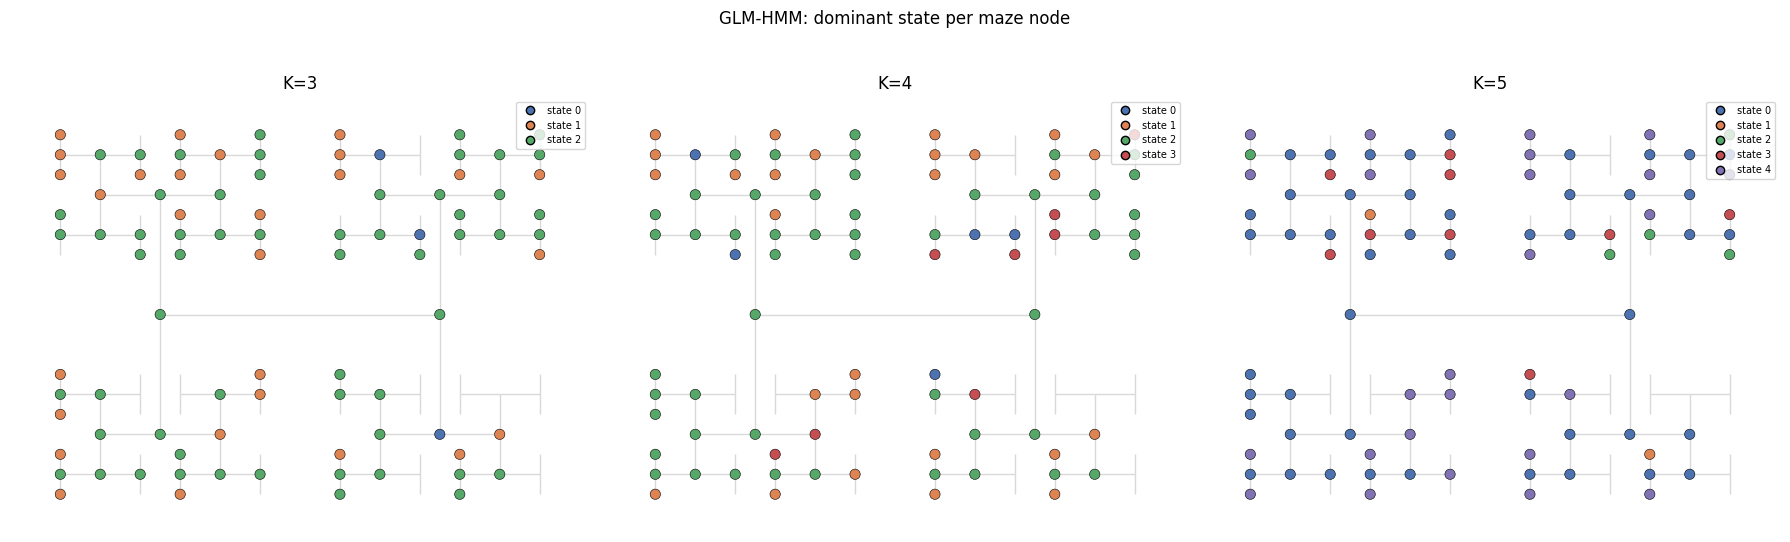

In [20]:
pos = nx.get_node_attributes(G, "pos")
fig, axes = plt.subplots(1, len(DEEPDIVE_K), figsize=(6 * len(DEEPDIVE_K), 6))
for ax, K in zip(axes, DEEPDIVE_K):
    node_state = feat.groupby("node_name")[f"state_K{K}"].agg(lambda s: s.value_counts().idxmax())
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="0.85")
    xs = [pos[n][0] for n in node_state.index]; ys = [pos[n][1] for n in node_state.index]
    cols = [palette[int(s)] for s in node_state.values]
    ax.scatter(xs, ys, c=cols, s=55, edgecolors="k", linewidths=0.4, zorder=3)
    ax.invert_yaxis(); ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"K={K}")
    handles = [plt.Line2D([0], [0], marker="o", ls="", mfc=palette[i], mec="k", label=f"state {i}")
               for i in range(K)]
    ax.legend(handles=handles, loc="upper right", fontsize=7)
fig.suptitle("GLM-HMM: dominant state per maze node")
fig.tight_layout()
fig.savefig(OUT_DIR / "deepdive_maze_by_K.png", dpi=140)
plt.show()

### 4B.6 Summary statistics table, K = 3 / 4 / 5

In [21]:
rows = []
for K in DEEPDIVE_K:
    r = results[("IO-HMM", K)]
    rep = report_by_K[K]
    exploit = rep["enrichment"]["anchor_exploit"]
    explore = rep["enrichment"]["anchor_explore"]
    com = com_stats[K]
    pur = purity_stats[K]
    rows.append({
        "K": K,
        "logLik": round(r["ll"], 1),
        "BIC": round(r["bic"], 1),
        "most_sticky_state": max(rep["stickiness"], key=lambda s: rep["stickiness"][s]["p_self"]),
        "max_p_self": round(max(v["p_self"] for v in rep["stickiness"].values()), 2),
        "exploit_state": exploit["best_state"],
        "exploit_OR": round(exploit["best_odds_ratio"], 2),
        "exploit_p": f"{exploit['best_p']:.1e}",
        "explore_state": explore["best_state"],
        "explore_OR": round(explore["best_odds_ratio"], 2),
        "alternation_mean_purity": round(pur["mean_purity"], 3),
        "alternation_pct_pure": f"{pur['pct_pure']:.0%}",
        "com_state": com["best_state"],
        "com_capture_rate": f"{com['capture_rate']:.0%}",
        "com_baseline_occ": f"{com['baseline_occupancy']:.0%}",
        "com_OR": round(com["odds_ratio"], 2),
        "com_p": f"{com['p']:.2g}",
    })
summary_table = pd.DataFrame(rows).set_index("K")
summary_table.to_csv(OUT_DIR / "deepdive_summary_stats.csv")
display(summary_table.T)

K,3,4,5
logLik,-2549.6,-2567.1,-2583.4
BIC,7823.4,9220.5,10840.7
most_sticky_state,2,2,0
max_p_self,0.62,0.44,0.44
exploit_state,1,1,1
exploit_OR,6.39,3.02,2.45
exploit_p,2.1e-201,2.6e-76,9.5e-21
explore_state,2,2,0
explore_OR,2.32,3.55,1.49
alternation_mean_purity,0.553,0.519,0.477


## 5. Held-out turn prediction (does the state add predictive power?)

For the input-driven IO-HMM we compare held-out `turn_type` accuracy against two
baselines: the marginal turn frequency, and a state-free multinomial logistic
regression on the same covariates. States should improve prediction.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y = turn_out
# baseline 1: majority turn class
maj = pd.Series(y[TRAIN]).mode()[0]
acc_major = accuracy_score(y[TEST], np.full(TEST.sum(), maj))

# baseline 2: state-free multinomial logistic on covariates
# (no multi_class= kwarg: sklearn >=1.5 always uses multinomial for LogisticRegression)
lr = LogisticRegression(max_iter=500)
lr.fit(X[TRAIN], y[TRAIN])
acc_lr = accuracy_score(y[TEST], lr.predict(X[TEST]))

# with state: augment covariates with one-hot inferred state, refit logistic
st = feat["state"].values
onehot = pd.get_dummies(st).values.astype(float)
Xs = np.hstack([X, onehot])
lr2 = LogisticRegression(max_iter=500)
lr2.fit(Xs[TRAIN], y[TRAIN])
acc_state = accuracy_score(y[TEST], lr2.predict(Xs[TEST]))

print(f"held-out turn accuracy:")
print(f"  majority-class baseline : {acc_major:.3f}")
print(f"  covariates only (logit) : {acc_lr:.3f}")
print(f"  covariates + HMM state  : {acc_state:.3f}")

held-out turn accuracy:
  majority-class baseline : 0.317
  covariates only (logit) : 0.714
  covariates + HMM state  : 0.725


## 6. (Optional) Neural correspondence — Neuropixels spikes

Runs only if external spike data exists for this session
(`SpikesData/{DD_MM_YYYY}/`). Tests whether inferred **state switches** align with
firing-rate changes and whether states occupy separable population states.
Loading/PSTH machinery mirrors `change_of_mind.ipynb`.

In [23]:
DD, MM, YYYY = SESSION.split("_")
SPIKES_DIR = Path(f"/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD}_{MM}_{YYYY}")
HAS_NEURAL = (SPIKES_DIR / "aligned_spike_times.mat").exists()
print("SpikesData dir:", SPIKES_DIR, "| HAS_NEURAL =", HAS_NEURAL)

if not HAS_NEURAL:
    print("\nNo neural data for this session -> skipping neural section (this is expected "
          "for most dual_root_tree sessions).")
else:
    import scipy.io
    # state-switch frames = node-visit start frames where the inferred state changes
    sw = feat["state"].values
    switch_rows = np.where(np.diff(sw) != 0)[0] + 1
    switch_frames = feat["start_frame"].values[switch_rows]
    print(f"{len(switch_frames)} state-switch events to align spikes to.")
    print("Next: load aligned_spike_times.mat and reuse change_of_mind.ipynb "
          "gather_relative_spikes / binned_and_smoothed_rate + build_population_rate_matrix/run_pca "
          "to PSTH-align firing to these switch_frames and compare per-state PC occupancy.")

SpikesData dir: /var/home/almogmeir/Documents/M.Sc/Project/SpikesData/10_09_2025 | HAS_NEURAL = True
2400 state-switch events to align spikes to.
Next: load aligned_spike_times.mat and reuse change_of_mind.ipynb gather_relative_spikes / binned_and_smoothed_rate + build_population_rate_matrix/run_pca to PSTH-align firing to these switch_frames and compare per-state PC occupancy.


## 7. Save outputs

In [24]:
# persist per-node-visit states for the chosen model + the selection table
feat.to_csv(OUT_DIR / "node_states.csv", index=False)
sel.to_csv(OUT_DIR / "model_selection.csv", index=False)
with open(OUT_DIR / "validation_report.json", "w") as fh:
    json.dump({
        "session": SESSION, "chosen_family": CHOSEN_FAMILY, "chosen_K": CHOSEN_K,
        "enrichment": {a: {"best_state": d["best_state"],
                            "best_odds_ratio": d["best_odds_ratio"],
                            "best_p": d["best_p"], "n_anchor": d["n_anchor"]}
                       for a, d in report["enrichment"].items()},
        "occupancy": report["occupancy"],
        "stickiness": report["stickiness"],
    }, fh, indent=2)
print("wrote:", *[p.name for p in sorted(OUT_DIR.glob("*"))], sep="\n  ")

wrote:
  .~lock.node_states.csv#
  anchor_enrichment.png
  deepdive_alternation_purity.png
  deepdive_apex_zoom.png
  deepdive_change_of_mind.png
  deepdive_maze_by_K.png
  deepdive_raster_overview.png
  deepdive_summary_stats.csv
  deepdive_transition_matrices.png
  model_selection.csv
  model_selection.png
  node_states.csv
  state_feature_means.png
  state_on_maze.png
  state_raster.png
  validation_report.json


## Phase B — generalize to other sessions (next steps)

- Regenerate `node_df` for the other sessions via
  `navigraph.analysis.traversal_builder.build_node_df` (or reuse the existing
  `node_summary_df.csv`, which has an equivalent schema). `turn_type` no longer
  needs a precomputed `turn_df.csv` — it's derived from `G` directly — so every
  session with a `node_df`/`node_summary_df` can go straight through this pipeline.
- Refit the chosen family/K per session; also fit **pooled** across sessions by passing
  multiple sequences to IOHMM (`set_data([df1, df2, ...])`) for a shared state definition.
- Pool the `change_of_mind` apex anchors across sessions to raise power on the
  (per-session sparse, ~17) commitment validation.